In [1]:
library(Matrix)
library(xgboost)
library(ggplot2)
library(lattice)
library(caret)
library(dplyr)
library(tictoc)
library(recipes)


Attachement du package : ‘dplyr’


L'objet suivant est masqué depuis ‘package:xgboost’:

    slice


Les objets suivants sont masqués depuis ‘package:stats’:

    filter, lag


Les objets suivants sont masqués depuis ‘package:base’:

    intersect, setdiff, setequal, union



Attachement du package : ‘recipes’


L'objet suivant est masqué depuis ‘package:Matrix’:

    update


L'objet suivant est masqué depuis ‘package:stats’:

    step




In [2]:
data <- read.csv("data_target_encoding.csv",stringsAsFactors = T)
test <- read.csv("test_target_encoding.csv",stringsAsFactors = T)

In [3]:
dummy_data <- dummyVars(" ~ .", data=data)  
data.dummy <- data.frame(predict(dummy_data, newdata = data)) 

In [4]:
X.dummy <- sparse.model.matrix(damage_grade ~ .,data = data.dummy)[,-1]
y.dummy <- as.numeric(data.dummy[,c("damage_grade")]-1)

In [5]:
set.seed(2)

n<-ncol(data.dummy)
targets<-which(grepl('damage_grade',colnames(data.dummy)))
correlation<-abs(cor(data.dummy[,-targets,drop=F],data.dummy[,targets,drop=F]))
selected<-c()
candidates<-1:n

    #mRMR ranks the variables by taking account not only the correlation with the output, but also by avoiding redudant variables
    for (j in 1:n) {
        redundancy_score<-numeric(length(candidates))
        
        if (length(selected)>0) {
            # Compute the correlation between the selected variables and the candidates on the training set
            cor_selected_candidates<-cor(data.dummy[,selected,drop=F],data.dummy[,candidates,drop=F])
            # Compute the mean correlation for each candidate variable, across the selected variables
            redundancy_score<-apply(cor_selected_candidates,2,mean)
        }
        
        # mRMR: minimum Redundancy Maximum Relevancy
        mRMR_score<-correlation[candidates]-redundancy_score
        
        # Select the candidate variable that maximises the mRMR score
        selected_current<-candidates[which.max(mRMR_score)]
        selected<-c(selected,selected_current)
        
        # Remove the selected variables from the candidates
        candidates<-setdiff(candidates,selected_current)
    }
    
    ranking.dummy <- selected

In [6]:
ranking.dummy
colnames(data.dummy)[ranking.dummy]

[1]  5 24 22  3  2 50 16  1 18 21 46 15  4 28 27 29 17 19 54 20 53  6  7 51 56
[26]  9 30 58 52 62 47 63 33 45 34 44 37 60 48 59  8 55 64 35 25 36 26 23 42 31
[51] 61 12 13 11 41 14 70 43 10 66 65 68 67 57 39 40 69 38 49 32

[1] "geo_level_3_mean_damage"               
 [2] "ground_floor_type.v"                   
 [3] "ground_floor_type.f"                   
 [4] "geo_level_2_mean_damage"               
 [5] "geo_level_1_sd_damage"                 
 [6] "has_superstructure_cement_mortar_brick"
 [7] "foundation_type.r"                     
 [8] "geo_level_1_mean_damage"               
 [9] "foundation_type.w"                     
[10] "roof_type.x"                           
[11] "has_superstructure_mud_mortar_stone"   
[12] "foundation_type.i"                     
[13] "geo_level_2_sd_damage"                 
[14] "other_floor_type.q"                    
[15] "other_floor_type.j"                    
[16] "other_floor_type.s"                    
[17] "foundation_type.u"                     
[18] "roof_type.n"                           
[19] "has_superstructure_rc_engineered"      
[20] "roof_type.q"                           
[21] "has_superstructure_rc_non_engineered"  
[22] "geo_level_3_sd_damage"                 
[23] "count_floors_pre_eq"                   
[24] "has_superstructure_timber"             
[25] "legal_ownership_status.a"              
[26] "area_percentage"                       
[27] "other_floor_type.x"                    
[28] "legal_ownership_status.v"              
[29] "has_superstructure_bamboo"             
[30] "has_secondary_use_hotel"               
[31] "has_superstructure_stone_flag"         
[32] "has_secondary_use_rental"              
[33] "position.s"                            
[34] "has_superstructure_adobe_mud"          
[35] "position.t"                            
[36] "plan_configuration.u"                  
[37] "plan_configuration.d"                  
[38] "count_families"                        
[39] "has_superstructure_cement_mortar_stone"
[40] "legal_ownership_status.w"              
[41] "age"                                   
[42] "has_superstructure_other"              
[43] "has_secondary_use_institution"         
[44] "plan_configuration.a"                  
[45] "ground_floor_type.x"                   
[46] "plan_configuration.c"                  
[47] "ground_floor_type.z"                   
[48] "ground_floor_type.m"                   
[49] "plan_configuration.q"                  
[50] "position.j"                            
[51] "has_secondary_use_agriculture"         
[52] "land_surface_condition.o"              
[53] "land_surface_condition.t"              
[54] "land_surface_condition.n"              
[55] "plan_configuration.o"                  
[56] "foundation_type.h"                     
[57] "has_secondary_use_other"               
[58] "plan_configuration.s"                  
[59] "height_percentage"                     
[60] "has_secondary_use_industry"            
[61] "has_secondary_use_school"              
[62] "has_secondary_use_gov_office"          
[63] "has_secondary_use_health_post"         
[64] "legal_ownership_status.r"              
[65] "plan_configuration.m"                  
[66] "plan_configuration.n"                  
[67] "has_secondary_use_use_police"          
[68] "plan_configuration.f"                  
[69] "has_superstructure_mud_mortar_brick"   
[70] "position.o"

In [8]:
one_feature_remove <- c(19,20,27,28,29,30,39,40,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70)

In [10]:
set.seed(1)
k = 5
accuracy_vec <- 1:k

tic()
X.dummy.f  <- X.dummy[,ranking.dummy[-one_feature_remove]]
    
spam_idx <- sample(1:nrow(X.dummy.f))
max <- ceiling(nrow(X.dummy.f)/k)
splits <- split(spam_idx, ceiling(seq_along(spam_idx)/max)) 
    
pb2 <- txtProgressBar(min = 1, max = k, style = 3)
    
for (i in 1:k){
    X.dummy.f.test <- X.dummy.f[splits[[i]],]
    y.dummy.test <- y.dummy[splits[[i]]]
    X.dummy.f.train <- X.dummy.f[-splits[[i]],]
    y.dummy.train <- y.dummy[-splits[[i]]]
    
    grid_default <- expand.grid(
    nrounds = 100,
    max_depth = 6,
    eta = 0.3,
    gamma = 0,
    colsample_bytree = 1,
    min_child_weight = 1,
    subsample = 1
    )
        
    train_control <- caret::trainControl(
    method = "none",
    verboseIter = FALSE, # no training log
    allowParallel = TRUE, # FALSE for reproducible results 
    summaryFunction = multiClassSummary
    )

    xgb_model <- caret::train(
    x = X.dummy.f.train,
    y = as.factor(y.dummy.train),
    trControl = train_control,
    tuneGrid = grid_default,
    method = "xgbTree",
    verbose = TRUE
    )

    pred <- predict(xgb_model, X.dummy.f.test)
    ll <- length(y.dummy.test)
    cfm <- matrix(0, nrow = 3, ncol = 3)
    for (j in 1:ll){cfm[pred[j],(y.dummy.test[j]+1)] <- cfm[pred[j],(y.dummy.test[j]+1)]+1}
    TP <- c(cfm[1,1],cfm[2,2],cfm[3,3])
    FP <- c(cfm[2,1]+cfm[3,1],cfm[1,2]+cfm[3,2],cfm[1,3]+cfm[2,3])
    FN <- c(cfm[1,2]+cfm[1,3],cfm[2,1]+cfm[2,3],cfm[3,1]+cfm[3,2])
    P_micro <- sum(TP)/sum(TP+FP)
    R_micro <- sum(TP)/sum(TP+FN)
    accuracy_vec[i] <- (2*P_micro*R_micro)/(P_micro+R_micro)
    
    setTxtProgressBar(pb2, i)
    print((2*P_micro*R_micro)/(P_micro+R_micro))   
    
}
mean(accuracy_vec)
toc()

  |                                                                      |   0%[1] 0.7601543
  |==================                                                    |  25%[1] 0.7590031
  |===================================                                   |  50%[1] 0.7597705
  |====================================================                  |  75%[1] 0.7621304
  |======================================================================| 100%[1] 0.7614982


[1] 0.7605113

178.783 sec elapsed


On vas maintenant proceder au tuning des paramaetre

On enleve tous d'abord les feature pour avoir un proces plus rappide 

In [9]:
ranking.dummy[one_feature_remove]
colnames(data.dummy)[ranking.dummy[one_feature_remove]]

[1] 54 20 30 58 52 62 48 59 64 35 25 36 26 23 42 31 61 12 13 11 41 14 70 43 10
[26] 66 65 68 67 57 39 40 69 38 49 32

[1] "has_superstructure_rc_engineered"      
 [2] "roof_type.q"                           
 [3] "other_floor_type.x"                    
 [4] "legal_ownership_status.v"              
 [5] "has_superstructure_bamboo"             
 [6] "has_secondary_use_hotel"               
 [7] "has_superstructure_cement_mortar_stone"
 [8] "legal_ownership_status.w"              
 [9] "has_secondary_use_institution"         
[10] "plan_configuration.a"                  
[11] "ground_floor_type.x"                   
[12] "plan_configuration.c"                  
[13] "ground_floor_type.z"                   
[14] "ground_floor_type.m"                   
[15] "plan_configuration.q"                  
[16] "position.j"                            
[17] "has_secondary_use_agriculture"         
[18] "land_surface_condition.o"              
[19] "land_surface_condition.t"              
[20] "land_surface_condition.n"              
[21] "plan_configuration.o"                  
[22] "foundation_type.h"                     
[23] "has_secondary_use_other"               
[24] "plan_configuration.s"                  
[25] "height_percentage"                     
[26] "has_secondary_use_industry"            
[27] "has_secondary_use_school"              
[28] "has_secondary_use_gov_office"          
[29] "has_secondary_use_health_post"         
[30] "legal_ownership_status.r"              
[31] "plan_configuration.m"                  
[32] "plan_configuration.n"                  
[33] "has_secondary_use_use_police"          
[34] "plan_configuration.f"                  
[35] "has_superstructure_mud_mortar_brick"   
[36] "position.o"

In [14]:
data.dummy[1:2,]

,geo_level_1_mean_damage,geo_level_1_sd_damage,geo_level_2_mean_damage,geo_level_2_sd_damage,geo_level_3_mean_damage,geo_level_3_sd_damage,count_floors_pre_eq,age,area_percentage,height_percentage,⋯,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2.020477,0.4558226,1.984293,0.2987067,1.971429,0.1690309,1,25,5,2,⋯,0,0,0,0,0,0,0,0,0,2
2,2.794480,0.4352255,2.977444,0.1490457,3.000000,0.0000000,2,0,13,7,⋯,0,0,0,0,0,0,0,0,0,3


In [10]:
new_data.dummy <- data.dummy[,-ranking.dummy[one_feature_remove]]

In [16]:
dim(new_data.dummy)

[1] 260601     35

In [11]:
X <- sparse.model.matrix(damage_grade ~ .,data = new_data.dummy)[,-1]
y <- as.numeric(new_data.dummy[,c("damage_grade")]-1)

In [43]:
y[1:20]

[1] 1 2 2 1 1 0 2 2 1 0 1 1 2 1 1 1 0 1 1 2

teston le changer le nrounds

In [19]:
set.seed(2)
k = 5
accuracy_vec <- 1:k

tic()
spam_idx <- sample(1:nrow(X))
max <- ceiling(nrow(X)/k)
splits <- split(spam_idx, ceiling(seq_along(spam_idx)/max)) 
    
pb2 <- txtProgressBar(min = 1, max = k, style = 3)
    
for (i in 1:k){
    X.test <- X[splits[[i]],]
    y.test <- y[splits[[i]]]
    X.train <- X[-splits[[i]],]
    y.train <- y[-splits[[i]]]
    
    grid_default <- expand.grid(
    nrounds = 100,
    max_depth = 6,
    eta = 0.3,
    gamma = 0,
    colsample_bytree = 1,
    min_child_weight = 1,
    subsample = 1
    )
        
    train_control <- caret::trainControl(
    method = "none",
    verboseIter = FALSE, # no training log
    allowParallel = TRUE, # FALSE for reproducible results 
    summaryFunction = multiClassSummary
    )

    xgb_model <- caret::train(
    x = X.train,
    y = as.factor(y.train),
    trControl = train_control,
    tuneGrid = grid_default,
    method = "xgbTree",
    verbose = TRUE
    )

    pred <- predict(xgb_model, X.test)
    ll <- length(y.test)
    cfm <- matrix(0, nrow = 3, ncol = 3)
    for (j in 1:ll){cfm[pred[j],(y.test[j]+1)] <- cfm[pred[j],(y.test[j]+1)]+1}
    TP <- c(cfm[1,1],cfm[2,2],cfm[3,3])
    FP <- c(cfm[2,1]+cfm[3,1],cfm[1,2]+cfm[3,2],cfm[1,3]+cfm[2,3])
    FN <- c(cfm[1,2]+cfm[1,3],cfm[2,1]+cfm[2,3],cfm[3,1]+cfm[3,2])
    P_micro <- sum(TP)/sum(TP+FP)
    R_micro <- sum(TP)/sum(TP+FN)
    accuracy_vec[i] <- (2*P_micro*R_micro)/(P_micro+R_micro)
    
    setTxtProgressBar(pb2, i)
    print((2*P_micro*R_micro)/(P_micro+R_micro))   
    
}
mean(accuracy_vec)
toc()

  |                                                                      |   0%[1] 0.7605955
  |==================                                                    |  25%[1] 0.7580054
  |===================================                                   |  50%[1] 0.7611136
  |====================================================                  |  75%[1] 0.7612479
  |======================================================================| 100%[1] 0.7595027


[1] 0.760093

198.165 sec elapsed


In [13]:
set.seed(2)
k = 5
accuracy_matrix <- matrix(0, 3, ncol = k)

tic()
spam_idx <- sample(1:nrow(X))
max <- ceiling(nrow(X)/k)
splits <- split(spam_idx, ceiling(seq_along(spam_idx)/max)) 
pb1 <- txtProgressBar(min = 1, max = 3, style = 2)

indice_bar <- 1
for (nrounds in c(50,100,150)){
    tic()
    pb2 <- txtProgressBar(min = 1, max = k, style = 3)
    
    for (i in 1:k){
        X.test <- X[splits[[i]],]
        y.test <- y[splits[[i]]]
        X.train <- X[-splits[[i]],]
        y.train <- y[-splits[[i]]]
    
        grid_default <- expand.grid(
        nrounds = nrounds,
        max_depth = 6,
        eta = 0.3,
        gamma = 0,
        colsample_bytree = 1,
        min_child_weight = 1,
        subsample = 1
        )
        
        train_control <- caret::trainControl(
        method = "none",
        verboseIter = FALSE, # no training log
        allowParallel = TRUE, # FALSE for reproducible results 
        summaryFunction = multiClassSummary
        )

        xgb_model <- caret::train(
        x = X.train,
        y = as.factor(y.train),
        trControl = train_control,
        tuneGrid = grid_default,
        method = "xgbTree",
        verbose = TRUE
        )

        pred <- predict(xgb_model, X.test)
        ll <- length(y.test)
        cfm <- matrix(0, nrow = 3, ncol = 3)
        for (j in 1:ll){cfm[pred[j],(y.test[j]+1)] <- cfm[pred[j],(y.test[j]+1)]+1}
        TP <- c(cfm[1,1],cfm[2,2],cfm[3,3])
        FP <- c(cfm[2,1]+cfm[3,1],cfm[1,2]+cfm[3,2],cfm[1,3]+cfm[2,3])
        FN <- c(cfm[1,2]+cfm[1,3],cfm[2,1]+cfm[2,3],cfm[3,1]+cfm[3,2])
        P_micro <- sum(TP)/sum(TP+FP)
        R_micro <- sum(TP)/sum(TP+FN)
        accuracy_matrix[indice_bar,i] <- (2*P_micro*R_micro)/(P_micro+R_micro)
    
        setTxtProgressBar(pb2, i)
        print((2*P_micro*R_micro)/(P_micro+R_micro))   
    
    }
    toc()
setTxtProgressBar(pb1, indice_bar)
print(mean(accuracy_matrix[indice_bar,]))
indice_bar <- indice_bar+1
    
}


  |                                                                      |   0%[1] 0.7608066
  |==================                                                    |  25%[1] 0.7578327
  |===================================                                   |  50%[1] 0.7614205
  |====================================================                  |  75%[1] 0.7602502
  |======================================================================| 100%[1] 0.7592532
96.796 sec elapsed
  |                                                                      |   0%[1] 0.7605955
  |==================                                                    |  25%[1] 0.7580054
  |===================================                                   |  50%[1] 0.7611136
  |====================================================                  |  75%[1] 0.7612479
  |======================================================================| 100%[1] 0.7595027
181.938 sec elapsed
  |                            

In [16]:
as.matrix(accuracy_matrix) %*% c(1/5,1/5,1/5,1/5,1/5)

0.7599127
0.7600930
0.7601390


In [21]:
set.seed(2)
k = 5
accuracy_vec <- 1:k

tic()
spam_idx <- sample(1:nrow(X))
max <- ceiling(nrow(X)/k)
splits <- split(spam_idx, ceiling(seq_along(spam_idx)/max)) 
    
pb2 <- txtProgressBar(min = 1, max = k, style = 3)
    
for (i in 1:k){
    X.test <- X[splits[[i]],]
    y.test <- y[splits[[i]]]
    X.train <- X[-splits[[i]],]
    y.train <- y[-splits[[i]]]
    
    grid_default <- expand.grid(
    nrounds = 100,
    max_depth = 6,
    eta = 0.3,
    gamma = 0,
    colsample_bytree = 1,
    min_child_weight = 1,
    subsample = 1
    )
        
    train_control <- caret::trainControl(
    method = "none",
    verboseIter = FALSE, # no training log
    allowParallel = TRUE, # FALSE for reproducible results 
    summaryFunction = f1
    )

    xgb_model <- caret::train(
    x = X.train,
    y = as.factor(y.train),
    trControl = train_control,
    tuneGrid = grid_default,
    method = "xgbTree",
    verbose = TRUE,
    metric = "F1"
    )

    pred <- predict(xgb_model, X.test)
    ll <- length(y.test)
    cfm <- matrix(0, nrow = 3, ncol = 3)
    for (j in 1:ll){cfm[pred[j],(y.test[j]+1)] <- cfm[pred[j],(y.test[j]+1)]+1}
    TP <- c(cfm[1,1],cfm[2,2],cfm[3,3])
    FP <- c(cfm[2,1]+cfm[3,1],cfm[1,2]+cfm[3,2],cfm[1,3]+cfm[2,3])
    FN <- c(cfm[1,2]+cfm[1,3],cfm[2,1]+cfm[2,3],cfm[3,1]+cfm[3,2])
    P_micro <- sum(TP)/sum(TP+FP)
    R_micro <- sum(TP)/sum(TP+FN)
    accuracy_vec[i] <- (2*P_micro*R_micro)/(P_micro+R_micro)
    
    setTxtProgressBar(pb2, i)
    print((2*P_micro*R_micro)/(P_micro+R_micro))   
    
}
mean(accuracy_vec)
toc()

  |                                                                      |   0%[1] 0.7605955
  |==================                                                    |  25%[1] 0.7580054
  |===================================                                   |  50%[1] 0.7611136


In [64]:
f1 <- function(data, lev = NULL, model = NULL) {
    f1_val <- f1_score(data$pred,data$obs)
    names(f1_val) <- c("F1")
    f1_val
}

f1_score <- function(predicted, expected) {
    predicted <- factor(as.character(predicted), levels=c('0','1','2'))
    expected  <- as.factor(expected)
    cm = as.matrix(table(expected, predicted))
    
    TP <- c(cm[1,1],cm[2,2],cm[3,3])
    FP <- c(cm[2,1]+cm[3,1],cm[1,2]+cm[3,2],cm[1,3]+cm[2,3])
    FN <- c(cm[1,2]+cm[1,3],cm[2,1]+cm[2,3],cm[3,1]+cm[3,2])
    P_micro <- sum(TP)/sum(TP+FP)
    R_micro <- sum(TP)/sum(TP+FN)
    f1 <-  (2*P_micro*R_micro)/(P_micro+R_micro)
    f1
}

In [32]:
?diag

In [65]:
set.seed(2)

tic()
grid_default <- expand.grid(
  nrounds = c(70,80,90,100,110,120),
  max_depth = 6,
  eta = 0.3,
  gamma = 0,
  colsample_bytree = 1,
  min_child_weight = 1,
  subsample = 1
)

train_control <- caret::trainControl(
    method = "cv",
    number = 5,
    verboseIter = FALSE, # no training log
    allowParallel = TRUE, # FALSE for reproducible results 
    summaryFunction =  f1
)

xgb_model <- caret::train(
    x = X,
    y = as.factor(y),
    trControl = train_control,
    tuneGrid = grid_default,
    method = "xgbTree",
    verbose = FALSE,
    metric = "F1"
)
toc()

[00:28:47] WARNING: src/c_api/c_api.cc:935: `ntree_limit` is deprecated, use `iteration_range` instead.
[00:28:47] WARNING: src/c_api/c_api.cc:935: `ntree_limit` is deprecated, use `iteration_range` instead.
[00:28:47] WARNING: src/c_api/c_api.cc:935: `ntree_limit` is deprecated, use `iteration_range` instead.
[00:28:47] WARNING: src/c_api/c_api.cc:935: `ntree_limit` is deprecated, use `iteration_range` instead.
[00:28:47] WARNING: src/c_api/c_api.cc:935: `ntree_limit` is deprecated, use `iteration_range` instead.
[00:29:26] WARNING: src/c_api/c_api.cc:935: `ntree_limit` is deprecated, use `iteration_range` instead.
[00:29:26] WARNING: src/c_api/c_api.cc:935: `ntree_limit` is deprecated, use `iteration_range` instead.
[00:29:26] WARNING: src/c_api/c_api.cc:935: `ntree_limit` is deprecated, use `iteration_range` instead.
[00:29:26] WARNING: src/c_api/c_api.cc:935: `ntree_limit` is deprecated, use `iteration_range` instead.
[00:29:26] WARNING: src/c_api/c_api.cc:935: `ntree_limit` is dep

In [66]:
xgb_model$results

,eta,max_depth,gamma,colsample_bytree,min_child_weight,subsample,nrounds,F1,F1SD
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,0.3,6,0,1,1,1,70,0.7599894,0.0004898595
2,0.3,6,0,1,1,1,80,0.7602849,0.0007675888
3,0.3,6,0,1,1,1,90,0.7601429,0.0006870635
4,0.3,6,0,1,1,1,100,0.7599050,0.0006309826
5,0.3,6,0,1,1,1,110,0.7601467,0.0005528354
6,0.3,6,0,1,1,1,120,0.7601582,0.0006723948


In [67]:
xgb_model$bestTune

,nrounds,max_depth,eta,gamma,colsample_bytree,min_child_weight,subsample
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2,80,6,0.3,0,1,1,1


In [71]:
set.seed(2)

tic()
grid_default <- expand.grid(
  nrounds = (1:5)*50,
  max_depth = 6,
  eta = 0.3,
  gamma = 0,
  colsample_bytree = 1,
  min_child_weight = 1,
  subsample = 1
)

train_control <- caret::trainControl(
    method = "cv",
    number = 5,
    verboseIter = FALSE, # no training log
    allowParallel = TRUE, # FALSE for reproducible results 
    summaryFunction =  f1
)

xgb_model <- caret::train(
    x = X,
    y = as.factor(y),
    trControl = train_control,
    tuneGrid = grid_default,
    method = "xgbTree",
    verbose = FALSE,
    metric = "F1"
)
toc()

[00:45:50] WARNING: src/c_api/c_api.cc:935: `ntree_limit` is deprecated, use `iteration_range` instead.
[00:45:50] WARNING: src/c_api/c_api.cc:935: `ntree_limit` is deprecated, use `iteration_range` instead.
[00:45:50] WARNING: src/c_api/c_api.cc:935: `ntree_limit` is deprecated, use `iteration_range` instead.
[00:45:50] WARNING: src/c_api/c_api.cc:935: `ntree_limit` is deprecated, use `iteration_range` instead.
[00:47:11] WARNING: src/c_api/c_api.cc:935: `ntree_limit` is deprecated, use `iteration_range` instead.
[00:47:11] WARNING: src/c_api/c_api.cc:935: `ntree_limit` is deprecated, use `iteration_range` instead.
[00:47:11] WARNING: src/c_api/c_api.cc:935: `ntree_limit` is deprecated, use `iteration_range` instead.
[00:47:11] WARNING: src/c_api/c_api.cc:935: `ntree_limit` is deprecated, use `iteration_range` instead.
[00:48:32] WARNING: src/c_api/c_api.cc:935: `ntree_limit` is deprecated, use `iteration_range` instead.
[00:48:32] WARNING: src/c_api/c_api.cc:935: `ntree_limit` is dep

In [72]:
xgb_model$results

,eta,max_depth,gamma,colsample_bytree,min_child_weight,subsample,nrounds,F1,F1SD
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,0.3,6,0,1,1,1,50,0.7595788,0.0010853209
2,0.3,6,0,1,1,1,100,0.7605458,0.0009485747
3,0.3,6,0,1,1,1,150,0.7603539,0.0013425472
4,0.3,6,0,1,1,1,200,0.7601736,0.0012130807
5,0.3,6,0,1,1,1,250,0.7598282,0.0010979858


In [73]:
xgb_model$bestTune

,nrounds,max_depth,eta,gamma,colsample_bytree,min_child_weight,subsample
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2,100,6,0.3,0,1,1,1


In [76]:
set.seed(2)

tic()
grid_default <- expand.grid(
  nrounds = 100,
  max_depth = c(2,4,6,8,10,12),
  eta = 0.3,
  gamma = 0,
  colsample_bytree = 1,
  min_child_weight = 1,
  subsample = 1
)

train_control <- caret::trainControl(
    method = "cv",
    number = 5,
    verboseIter = FALSE, # no training log
    allowParallel = TRUE, # FALSE for reproducible results 
    summaryFunction =  f1
)

xgb_model <- caret::train(
    x = X,
    y = as.factor(y),
    trControl = train_control,
    tuneGrid = grid_default,
    method = "xgbTree",
    verbose = FALSE,
    metric = "F1"
)
toc()

1258.115 sec elapsed


In [77]:
xgb_model$results

,eta,max_depth,gamma,colsample_bytree,min_child_weight,subsample,nrounds,F1,F1SD
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,0.3,2,0,1,1,1,100,0.7558413,0.0007635597
2,0.3,4,0,1,1,1,100,0.7591836,0.0009622480
3,0.3,6,0,1,1,1,100,0.7605458,0.0009485747
4,0.3,8,0,1,1,1,100,0.7599318,0.0009577015
5,0.3,10,0,1,1,1,100,0.7574261,0.0010753439
6,0.3,12,0,1,1,1,100,0.7537615,0.0014726284


In [78]:
xgb_model$bestTune

,nrounds,max_depth,eta,gamma,colsample_bytree,min_child_weight,subsample
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
3,100,6,0.3,0,1,1,1


In [79]:
set.seed(2)

tic()
grid_default <- expand.grid(
  nrounds = 100,
  max_depth = 6,
  eta = c(0.025, 0.05, 0.1, 0.3),
  gamma = 0,
  colsample_bytree = 1,
  min_child_weight = 1,
  subsample = 1
)

train_control <- caret::trainControl(
    method = "cv",
    number = 5,
    verboseIter = FALSE, # no training log
    allowParallel = TRUE, # FALSE for reproducible results 
    summaryFunction =  f1
)

xgb_model <- caret::train(
    x = X,
    y = as.factor(y),
    trControl = train_control,
    tuneGrid = grid_default,
    method = "xgbTree",
    verbose = FALSE,
    metric = "F1"
)
toc()

726.158 sec elapsed


In [80]:
xgb_model$results

,eta,max_depth,gamma,colsample_bytree,min_child_weight,subsample,nrounds,F1,F1SD
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,0.025,6,0,1,1,1,100,0.7540109,0.0010805708
2,0.050,6,0,1,1,1,100,0.7569426,0.0009603636
3,0.100,6,0,1,1,1,100,0.7591260,0.0010856442
4,0.300,6,0,1,1,1,100,0.7605458,0.0009485747


In [81]:
xgb_model$bestTune

,nrounds,max_depth,eta,gamma,colsample_bytree,min_child_weight,subsample
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
4,100,6,0.3,0,1,1,1


In [82]:
set.seed(2)

tic()
grid_default <- expand.grid(
  nrounds = 100,
  max_depth = 6,
  eta = c(0.2, 0.3 ,0.4),
  gamma = 0,
  colsample_bytree = 1,
  min_child_weight = 1,
  subsample = 1
)

train_control <- caret::trainControl(
    method = "cv",
    number = 5,
    verboseIter = FALSE, # no training log
    allowParallel = TRUE, # FALSE for reproducible results 
    summaryFunction =  f1
)

xgb_model <- caret::train(
    x = X,
    y = as.factor(y),
    trControl = train_control,
    tuneGrid = grid_default,
    method = "xgbTree",
    verbose = FALSE,
    metric = "F1"
)

toc()

545.14 sec elapsed


In [83]:
xgb_model$results

,eta,max_depth,gamma,colsample_bytree,min_child_weight,subsample,nrounds,F1,F1SD
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,0.2,6,0,1,1,1,100,0.7601889,0.0012944430
2,0.3,6,0,1,1,1,100,0.7605458,0.0009485747
3,0.4,6,0,1,1,1,100,0.7602235,0.0007693847


In [84]:
xgb_model$bestTune

,nrounds,max_depth,eta,gamma,colsample_bytree,min_child_weight,subsample
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2,100,6,0.3,0,1,1,1


In [85]:
x$results$F1

ERROR: Error in eval(expr, envir, enclos): objet 'x' introuvable


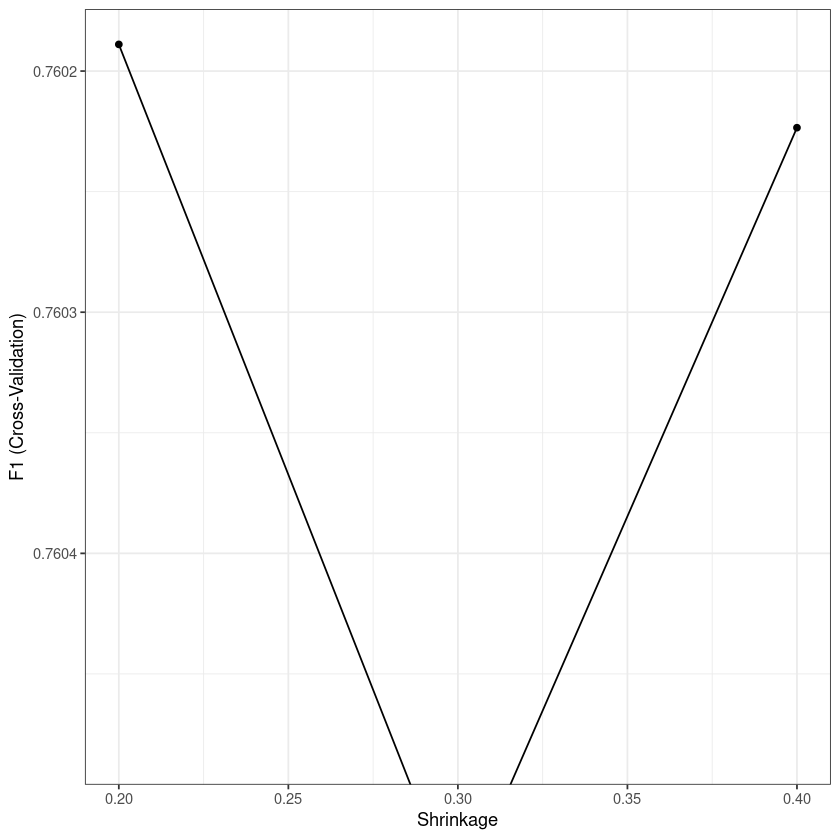

In [87]:
# helper function for the plots
tuneplot <- function(x, probs = .90) {
  ggplot(x) +
    coord_cartesian(ylim = c(quantile(x$results$F1, probs = probs), min(x$results$F1))) +
    theme_bw()
}

tuneplot(xgb_model)

On vas quand même rester sur notre feature selection qui maximise le score f1 quitte a avoir un temps de calcule plus long 

In [89]:
two_feature_remove <- c(19,20,27,28,39,40,43,44,45,46,53,54,55,56)

In [90]:
ranking.dummy[two_feature_remove]
colnames(data.dummy)[ranking.dummy[two_feature_remove]]

[1] 54 20 30 58 48 59 64 35 25 36 13 11 41 14

[1] "has_superstructure_rc_engineered"      
 [2] "roof_type.q"                           
 [3] "other_floor_type.x"                    
 [4] "legal_ownership_status.v"              
 [5] "has_superstructure_cement_mortar_stone"
 [6] "legal_ownership_status.w"              
 [7] "has_secondary_use_institution"         
 [8] "plan_configuration.a"                  
 [9] "ground_floor_type.x"                   
[10] "plan_configuration.c"                  
[11] "land_surface_condition.t"              
[12] "land_surface_condition.n"              
[13] "plan_configuration.o"                  
[14] "foundation_type.h"

In [91]:
new_data.dummy <- data.dummy[,-ranking.dummy[two_feature_remove]]
X <- sparse.model.matrix(damage_grade ~ .,data = new_data.dummy)[,-1]
y <- as.numeric(new_data.dummy[,c("damage_grade")]-1)

In [92]:
set.seed(2)
k = 5
accuracy_vec <- 1:k

tic()
spam_idx <- sample(1:nrow(X))
max <- ceiling(nrow(X)/k)
splits <- split(spam_idx, ceiling(seq_along(spam_idx)/max)) 
    
pb2 <- txtProgressBar(min = 1, max = k, style = 3)
    
for (i in 1:k){
    X.test <- X[splits[[i]],]
    y.test <- y[splits[[i]]]
    X.train <- X[-splits[[i]],]
    y.train <- y[-splits[[i]]]
    
    grid_default <- expand.grid(
    nrounds = 100,
    max_depth = 6,
    eta = 0.3,
    gamma = 0,
    colsample_bytree = 1,
    min_child_weight = 1,
    subsample = 1
    )
        
    train_control <- caret::trainControl(
    method = "none",
    verboseIter = FALSE, # no training log
    allowParallel = TRUE, # FALSE for reproducible results 
    summaryFunction = multiClassSummary
    )

    xgb_model <- caret::train(
    x = X.train,
    y = as.factor(y.train),
    trControl = train_control,
    tuneGrid = grid_default,
    method = "xgbTree",
    verbose = TRUE
    )

    pred <- predict(xgb_model, X.test)
    ll <- length(y.test)
    cfm <- matrix(0, nrow = 3, ncol = 3)
    for (j in 1:ll){cfm[pred[j],(y.test[j]+1)] <- cfm[pred[j],(y.test[j]+1)]+1}
    TP <- c(cfm[1,1],cfm[2,2],cfm[3,3])
    FP <- c(cfm[2,1]+cfm[3,1],cfm[1,2]+cfm[3,2],cfm[1,3]+cfm[2,3])
    FN <- c(cfm[1,2]+cfm[1,3],cfm[2,1]+cfm[2,3],cfm[3,1]+cfm[3,2])
    P_micro <- sum(TP)/sum(TP+FP)
    R_micro <- sum(TP)/sum(TP+FN)
    accuracy_vec[i] <- (2*P_micro*R_micro)/(P_micro+R_micro)
    
    setTxtProgressBar(pb2, i)
    print((2*P_micro*R_micro)/(P_micro+R_micro))   
    
}
mean(accuracy_vec)
toc()

  |                                                                      |   0%[1] 0.7612862
  |==================                                                    |  25%[1] 0.7594636
  |===================================                                   |  50%[1] 0.7633392
  |====================================================                  |  75%[1] 0.7625141
  |======================================================================| 100%[1] 0.7600783


[1] 0.7613363

288.301 sec elapsed


[02:21:16] WARNING: src/c_api/c_api.cc:935: `ntree_limit` is deprecated, use `iteration_range` instead.
[02:21:16] WARNING: src/c_api/c_api.cc:935: `ntree_limit` is deprecated, use `iteration_range` instead.
[02:21:16] WARNING: src/c_api/c_api.cc:935: `ntree_limit` is deprecated, use `iteration_range` instead.
[02:21:16] WARNING: src/c_api/c_api.cc:935: `ntree_limit` is deprecated, use `iteration_range` instead.
[02:22:36] WARNING: src/c_api/c_api.cc:935: `ntree_limit` is deprecated, use `iteration_range` instead.
[02:22:36] WARNING: src/c_api/c_api.cc:935: `ntree_limit` is deprecated, use `iteration_range` instead.
[02:22:36] WARNING: src/c_api/c_api.cc:935: `ntree_limit` is deprecated, use `iteration_range` instead.
[02:22:36] WARNING: src/c_api/c_api.cc:935: `ntree_limit` is deprecated, use `iteration_range` instead.
[02:24:13] WARNING: src/c_api/c_api.cc:935: `ntree_limit` is deprecated, use `iteration_range` instead.
[02:24:13] WARNING: src/c_api/c_api.cc:935: `ntree_limit` is dep

7200.741 sec elapsed


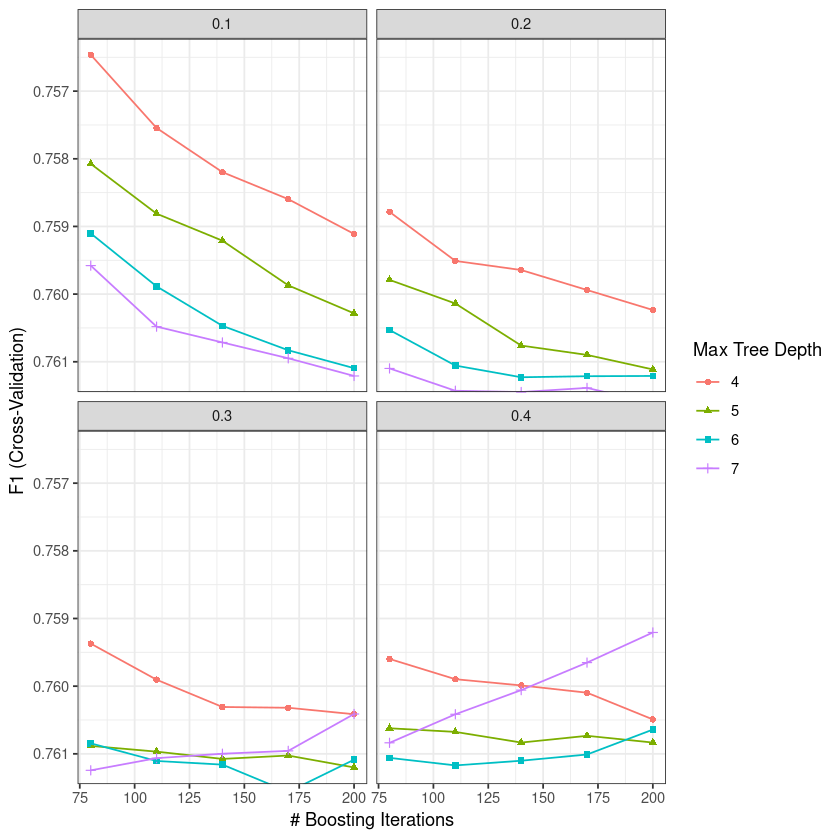

In [93]:
set.seed(2)

tic()
grid_default <- expand.grid(
  nrounds = (1:5)*30+50,
  max_depth = c(4,5,6,7),
  eta = c(0.1, 0.2, 0.3 ,0.4),
  gamma = 0,
  colsample_bytree = 1,
  min_child_weight = 1,
  subsample = 1
)

train_control <- caret::trainControl(
    method = "cv",
    number = 5,
    verboseIter = FALSE, # no training log
    allowParallel = TRUE, # FALSE for reproducible results 
    summaryFunction =  f1
)

xgb_model <- caret::train(
    x = X,
    y = as.factor(y),
    trControl = train_control,
    tuneGrid = grid_default,
    method = "xgbTree",
    verbose = FALSE,
    metric = "F1"
)

# helper function for the plots
tuneplot <- function(x, probs = .90) {
  ggplot(x) +
    coord_cartesian(ylim = c(quantile(x$results$F1, probs = probs), min(x$results$F1))) +
    theme_bw()
}

tuneplot(xgb_model)
toc()

In [94]:
xgb_model$bestTune

,nrounds,max_depth,eta,gamma,colsample_bytree,min_child_weight,subsample
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
40,200,7,0.2,0,1,1,1


In [95]:
xgb_model$results

,eta,max_depth,gamma,colsample_bytree,min_child_weight,subsample,nrounds,F1,F1SD
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,0.1,4,0,1,1,1,80,0.7564629,0.0013655247
21,0.2,4,0,1,1,1,80,0.7587845,0.0011539864
41,0.3,4,0,1,1,1,80,0.7593716,0.0012247766
61,0.4,4,0,1,1,1,80,0.7595980,0.0010039877
6,0.1,5,0,1,1,1,80,0.7580746,0.0009948949
26,0.2,5,0,1,1,1,80,0.7597899,0.0011279660
46,0.3,5,0,1,1,1,80,0.7608835,0.0013291493
66,0.4,5,0,1,1,1,80,0.7606226,0.0015058709
11,0.1,6,0,1,1,1,80,0.7591030,0.0007503879


In [ ]:
set.seed(2)

tic()
grid_default <- expand.grid(
  nrounds = (0:4)*30+200,
  max_depth = c(6,7,8,9),
  eta = c(0.1,0.15 ,0.2, 0.25),
  gamma = 0,
  colsample_bytree = 1,
  min_child_weight = 1,
  subsample = 1
)

train_control <- caret::trainControl(
    method = "cv",
    number = 5,
    verboseIter = FALSE, # no training log
    allowParallel = TRUE, # FALSE for reproducible results 
    summaryFunction =  f1
)

xgb_model_2 <- caret::train(
    x = X,
    y = as.factor(y),
    trControl = train_control,
    tuneGrid = grid_default,
    method = "xgbTree",
    verbose = FALSE,
    metric = "F1"
)

# helper function for the plots
tuneplot <- function(x, probs = .90) {
  ggplot(x) +
    coord_cartesian(ylim = c(quantile(x$results$F1, probs = probs), min(x$results$F1))) +
    theme_bw()
}

tuneplot(xgb_model_2)
toc()

In [ ]:
xgb_model_2$bestTune

In [ ]:
xgb_model_2$results